Popular MNIST dataset with tensorflow neural network framework

In [59]:
# imports
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
import numpy as np
import random

In [ ]:
# download and Load the MNIST dataset
mnist_dataset, mnist_info = tfds.load('mnist', with_info=True, as_supervised=True)

# split dataset into train and test datasets
train_dataset, test_dataset = mnist_dataset['train'], mnist_dataset['test']

RuntimeError: AttributeError: Failed to construct dataset "mnist", builder_kwargs "{'data_dir': None}": 'google._upb._message.FieldDescriptor' object has no attribute 'label'

In [21]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


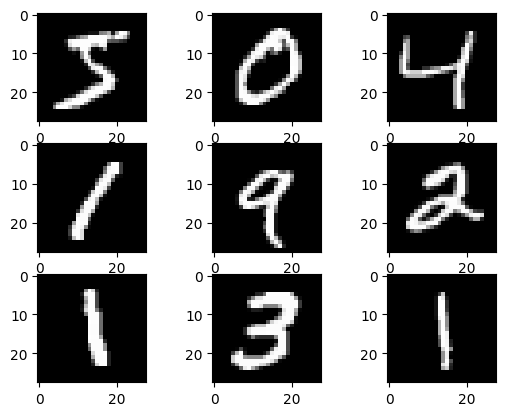

In [50]:
#Displaying the n first digits in the datset
for i in range(9):
  plt.subplot(330 + 1 + i) #rows col pos
  plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
plt.show()

In [51]:
model = models.Sequential([
layers.Flatten(input_shape=(28, 28)),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

model.summary()

s:\repositories\python\machine-learning\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Train the model
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8594 - loss: 2.3846
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9128 - loss: 0.3527
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9308 - loss: 0.2756
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9385 - loss: 0.2458
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9436 - loss: 0.2249


In [53]:
print(f'x shape {x_test.shape}')
print(f'y shape {y_test.shape}')
model.evaluate(x=x_test,y=y_test)

x shape (10000, 28, 28)
y shape (10000,)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0838 - loss: 179.1479


[179.1479034423828, 0.08380000293254852]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Y Label: 7, Prediction 4


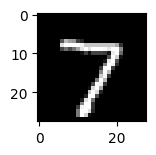

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Y Label: 2, Prediction 8


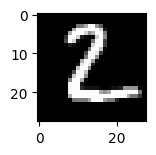

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Y Label: 1, Prediction 7


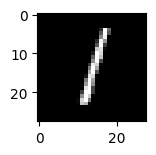

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Y Label: 0, Prediction 4


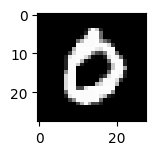

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Y Label: 4, Prediction 4


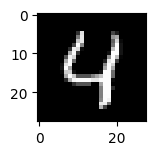

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Y Label: 1, Prediction 4


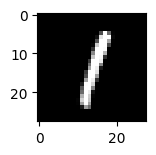

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Y Label: 4, Prediction 4


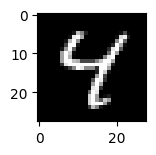

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Y Label: 9, Prediction 4


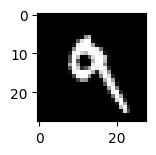

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Y Label: 5, Prediction 4


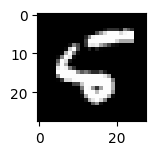

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Y Label: 9, Prediction 8


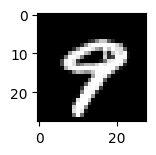

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Y Label: 0, Prediction 4


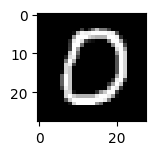

In [99]:
#selecting done random test data to predict over model
# input_index = random.randint(0, len(x_test));
# print(input_index)

for i in range(len(x_test)):
    #plotting input to see the content
    input = x_test[i]
    plt.subplot(330 + 1 + 1) #rows col pos
    plt.imshow(input, cmap=plt.get_cmap('gray'), label="input X")
    # predicting output
    output = np.argmax(model.predict(np.array([input])))
    print(f"Y Label: {y_test[i]}, Prediction {output}")   
    plt.show()
    if i == 10:
        break

